<a href="https://colab.research.google.com/github/Moysezg/financial-risk-management-var-models/blob/main/06_correlated_monte_carlo_var.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

/tmp/ipython-input-1910783122.py:48: FutureWarning: YF.download() has changed argument auto_adjust default to True
  datos = yf.download(self.tickers, start=inicio, end=fin)['Close']
[**********************71%*********              ]  5 of 7 completed

Iniciando Pipeline de Riesgo Monte Carlo...
Descargando datos históricos para: ['IVV', 'AVGO', 'LLY', 'NVDA', 'PM', 'WMT', 'XOM']


[*********************100%***********************]  7 of 7 completed


Calibrando matriz de covarianza y volatilidades...
Generando 10000 simulaciones usando Cholesky...
Calculando VaR y CVaR...
----------------------------------------
RESULTADOS DEL RIESGO (Horizonte: dt=0.0028, Confianza: 99.00%)
VaR  : -0.021151 (-2.1151%)
CVaR : -0.024239 (-2.4239%)
----------------------------------------
Exportando simulaciones a CSV...
Archivo guardado como: simulaciones_montecarlo_portafolio.csv
Generando visualizaciones...


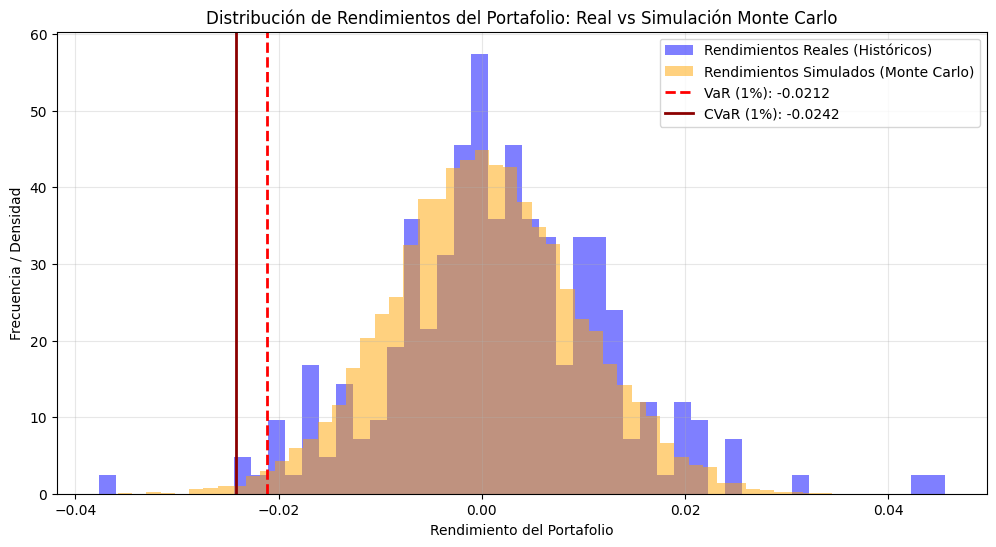

Pipeline ejecutado exitosamente.


In [ ]:
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
from scipy.stats import norm
import os

class RiesgoPortafolioPipeline:
    def __init__(self, tickers, pesos, r=0.04, n_sims=10000, dt=1/360, alpha=0.01):
        # 1. Inicialización de parámetros
        self.tickers = tickers
        self.pesos = np.array(pesos)
        self.r = r                     # Tasa libre de riesgo (media)
        self.n_sims = n_sims           # Número de simulaciones
        self.dt = dt                   # Diferencial de tiempo
        self.alpha = alpha             # Nivel de significancia para VaR

        # Variables de estado del pipeline
        self.datos_historicos = None
        self.rendimientos_historicos = None
        self.matriz_cov = None
        self.matriz_corr = None
        self.volatilidades = None

        self.Z = None                  # Normales independientes
        self.eta = None                # Normales correlacionadas
        self.rendimientos_simulados = None
        self.portafolio_simulado = None
        self.portafolio_real = None

        self.var = None
        self.cvar = None

    def ejecutar_pipeline(self, fecha_inicio='2022-01-01', fecha_fin='2024-01-01'):
        """Método orquestador que ejecuta los módulos de forma secuencial."""
        print("Iniciando Pipeline de Riesgo Monte Carlo...")
        self._ingesta_datos(fecha_inicio, fecha_fin)
        self._calibrar_parametros()
        self._simular_montecarlo()
        self._calcular_metricas_riesgo()
        self._exportar_csv()
        self._visualizar_resultados()
        print("Pipeline ejecutado exitosamente.")

    def _ingesta_datos(self, inicio, fin):
        """Módulo 1: Descarga de datos reales para obtener parámetros."""
        print(f"Descargando datos históricos para: {self.tickers}")
        datos = yf.download(self.tickers, start=inicio, end=fin)['Close']
        # Limpieza de datos y cálculo de rendimientos logarítmicos reales
        self.datos_historicos = datos.dropna()
        self.rendimientos_historicos = np.log(self.datos_historicos / self.datos_historicos.shift(1)).dropna()
        # Calculamos el rendimiento real del portafolio (para la gráfica posterior)
        self.portafolio_real = self.rendimientos_historicos.dot(self.pesos)

    def _calibrar_parametros(self):
        """Módulo 2: Paso 3 del requerimiento. Matriz de Varianza-Covarianza y Volatilidad."""
        print("Calibrando matriz de covarianza y volatilidades...")
        # Matriz de covarianza anualizada asumiendo 252 días bursátiles
        self.matriz_cov = self.rendimientos_historicos.cov() * 252
        # Matriz de correlación para el factor de Cholesky
        self.matriz_corr = self.rendimientos_historicos.corr()
        # Volatilidad en términos porcentuales (anualizada)
        self.volatilidades = self.rendimientos_historicos.std() * np.sqrt(252)

    def _simular_montecarlo(self):
        """Módulo 3: Pasos 4C, 4D y 4E del requerimiento."""
        print(f"Generando {self.n_sims} simulaciones usando Cholesky...")
        num_activos = len(self.tickers)

        # 4C) Generar variables aleatorias normales estándar independientes (Z)
        self.Z = np.random.standard_normal((self.n_sims, num_activos))

        # 4D) Algoritmo de Cholesky sobre la matriz de correlación
        L = np.linalg.cholesky(self.matriz_corr.values)

        # Crear normales dependientes (eta)
        self.eta = self.Z.dot(L.T)

        # 4E) Ecuación integro-diferencial: dS/S = r*dt + sigma*eta*sqrt(dt)
        # Vectorizamos la operación para todos los activos y simulaciones
        self.rendimientos_simulados = np.zeros_like(self.eta)
        for i in range(num_activos):
            sigma = self.volatilidades.iloc[i]
            # Rendimiento = (r * dt) + (sigma * eta * sqrt(dt))
            self.rendimientos_simulados[:, i] = (self.r * self.dt) + (sigma * self.eta[:, i] * np.sqrt(self.dt))

        # Proyectamos el portafolio multiplicando matricialmente simulaciones por pesos
        self.portafolio_simulado = self.rendimientos_simulados.dot(self.pesos)

    def _calcular_metricas_riesgo(self):
        """Módulo 4: Pasos 5, 6 y 7 del requerimiento."""
        print("Calculando VaR y CVaR...")
        # 5) VaR empírico basado en el cuantil de la distribución simulada
        self.var = np.percentile(self.portafolio_simulado, self.alpha * 100)

        # 6) CVaR empírico: promedio de las pérdidas que superan el VaR
        rendimientos_cola = self.portafolio_simulado[self.portafolio_simulado <= self.var]
        self.cvar = rendimientos_cola.mean()

        # 7) Mostrar resultados
        print("-" * 40)
        print(f"RESULTADOS DEL RIESGO (Horizonte: dt={self.dt:.4f}, Confianza: {1-self.alpha:.2%})")
        print(f"VaR  : {self.var:.6f} ({self.var*100:.4f}%)")
        print(f"CVaR : {self.cvar:.6f} ({self.cvar*100:.4f}%)")
        print("-" * 40)

    def _exportar_csv(self):
        """Módulo 5: Paso 4F del requerimiento."""
        print("Exportando simulaciones a CSV...")
        # Aplanamiento horizontal de matrices para un CSV estructurado
        df_Z = pd.DataFrame(self.Z, columns=[f'Z_{t}' for t in self.tickers])
        df_eta = pd.DataFrame(self.eta, columns=[f'eta_{t}' for t in self.tickers])
        df_rend = pd.DataFrame(self.rendimientos_simulados, columns=[f'Rendimiento_{t}' for t in self.tickers])

        # Concatenación en un solo DataFrame
        df_final = pd.concat([df_Z, df_eta, df_rend], axis=1)
        df_final['Portafolio_Simulado'] = self.portafolio_simulado

        ruta_archivo = 'simulaciones_montecarlo_portafolio.csv'
        df_final.to_csv(ruta_archivo, index=False)
        print(f"Archivo guardado como: {ruta_archivo}")

    def _visualizar_resultados(self):
        """Módulo 6: Paso 8 del requerimiento."""
        print("Generando visualizaciones...")
        plt.figure(figsize=(12, 6))

        # Adaptar la escala temporal de los datos reales (diarios) a la del dt definido
        # Nota: Asumimos dt para la simulación, pero graficamos densidades para comparabilidad

        # Graficar histograma de rendimientos reales
        plt.hist(self.portafolio_real, bins=50, density=True, alpha=0.5, color='blue', label='Rendimientos Reales (Históricos)')

        # Graficar histograma de rendimientos simulados (Monte Carlo)
        plt.hist(self.portafolio_simulado, bins=50, density=True, alpha=0.5, color='orange', label='Rendimientos Simulados (Monte Carlo)')

        # Marcar VaR y CVaR
        plt.axvline(self.var, color='red', linestyle='dashed', linewidth=2, label=f'VaR (1%): {self.var:.4f}')
        plt.axvline(self.cvar, color='darkred', linestyle='solid', linewidth=2, label=f'CVaR (1%): {self.cvar:.4f}')

        plt.title('Distribución de Rendimientos del Portafolio: Real vs Simulación Monte Carlo')
        plt.xlabel('Rendimiento del Portafolio')
        plt.ylabel('Frecuencia / Densidad')
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.show()

# ==========================================
# EJECUCIÓN DEL CÓDIGO
# ==========================================
if __name__ == "__main__":
    tickers_portafolio = ['IVV', 'AVGO', 'LLY', 'NVDA', 'PM', 'WMT', 'XOM']
    pesos_portafolio = [0.008442, 0.097029, 0.307739, 0.19164, 0.220718, 0.106888, 0.067544]

    # Instanciamos la clase con los parámetros por defecto solicitados
    modelo_riesgo = RiesgoPortafolioPipeline(
        tickers=tickers_portafolio,
        pesos=pesos_portafolio,
        r=0.04,
        n_sims=10000,
        dt=1/360,
        alpha=0.01
    )

    # Ejecutamos el pipeline (se descargan datos desde 2023 para capturar volatilidad reciente)
    modelo_riesgo.ejecutar_pipeline(fecha_inicio='2024-01-01', fecha_fin='2025-01-01')

/tmp/ipython-input-2961358676.py:51: FutureWarning: YF.download() has changed argument auto_adjust default to True
  datos = yf.download(self.tickers, start=inicio, end=fin)['Close']
[                       0%                       ]

Iniciando Pipeline de Riesgo Monte Carlo...
Descargando datos históricos para: ['IVV', 'AVGO', 'LLY', 'NVDA', 'PM', 'WMT', 'XOM']


[*********************100%***********************]  7 of 7 completed


Calibrando matriz de covarianza y volatilidades...
Generando 10000 simulaciones multivariadas...
Calculando Métricas de Riesgo de Cola (VaR y CVaR)...
--------------------------------------------------
MÉTRICAS DE RIESGO (Horizonte: dt=0.0028, Confianza: 99.00%)
VaR Empírico  : -0.020519
CVaR Empírico : -0.023796
--------------------------------------------------
Ejecutando pruebas de eficiencia (Kolmogorov-Smirnov y Anderson-Darling)...
--------------------------------------------------
RESULTADOS DE EFICIENCIA DE SIMULACIÓN (BONDAD DE AJUSTE)
H0: La distribución Monte Carlo replica la distribución histórica real.

1. Prueba Kolmogorov-Smirnov (KS):
   Estadístico D : 0.0814
   P-value       : 7.3370e-02
   => CONCLUSIÓN : No se rechaza H0. Simulación eficiente en el cuerpo central.

2. Prueba Anderson-Darling (AD):
   Estadístico AD: 3.8222
   P-value       : 9.4143e-03
   => CONCLUSIÓN : Se RECHAZA H0. Diferencia estadísticamente significativa, particularmente en las colas (riesgo e

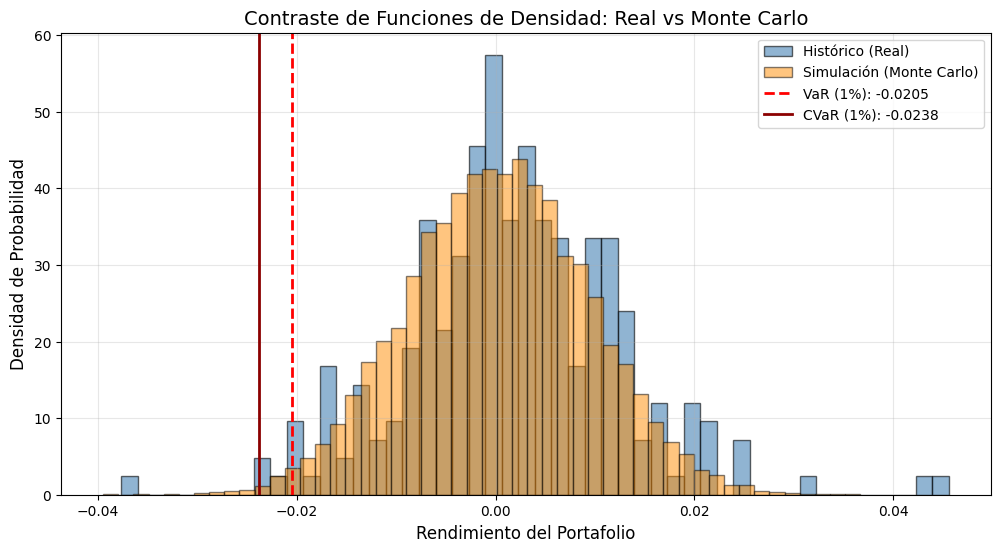

Pipeline ejecutado exitosamente.


In [ ]:
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
from scipy.stats import ks_2samp, anderson_ksamp
import warnings
import os

class RiesgoPortafolioPipeline:
    def __init__(self, tickers, pesos, r=0.04, n_sims=10000, dt=1/360, alpha=0.01):
        # 1. Inicialización de parámetros estructurales
        self.tickers = tickers
        self.pesos = np.array(pesos)
        self.r = r                     # Tasa libre de riesgo asintótica
        self.n_sims = n_sims           # N de trayectorias estocásticas
        self.dt = dt                   # Diferencial del paso de tiempo
        self.alpha = alpha             # Nivel de significancia empírica

        # Variables de almacenamiento de estado (Atributos del pipeline)
        self.datos_historicos = None
        self.rendimientos_historicos = None
        self.matriz_cov = None
        self.matriz_corr = None
        self.volatilidades = None

        self.Z = None                  # Matriz de innovaciones Gaussianas independientes
        self.eta = None                # Matriz de innovaciones correlacionadas (Cholesky)
        self.rendimientos_simulados = None
        self.portafolio_simulado = None
        self.portafolio_real = None

        self.var = None
        self.cvar = None

    def ejecutar_pipeline(self, fecha_inicio='2024-01-01', fecha_fin='2025-01-01'):
        """Método orquestador secuencial."""
        print("Iniciando Pipeline de Riesgo Monte Carlo...")
        self._ingesta_datos(fecha_inicio, fecha_fin)
        self._calibrar_parametros()
        self._simular_montecarlo()
        self._calcular_metricas_riesgo()
        # NUEVO MÓDULO: Validación de Eficiencia del Modelo
        self._evaluar_bondad_ajuste()
        self._exportar_csv()
        self._visualizar_resultados()
        print("Pipeline ejecutado exitosamente.")

    def _ingesta_datos(self, inicio, fin):
        """Módulo 1: Descarga y transformación de series de tiempo financieras."""
        print(f"Descargando datos históricos para: {self.tickers}")
        datos = yf.download(self.tickers, start=inicio, end=fin)['Close']
        self.datos_historicos = datos.dropna()
        # Cálculo de rendimientos continuos (logarítmicos)
        self.rendimientos_historicos = np.log(self.datos_historicos / self.datos_historicos.shift(1)).dropna()
        # Proyección lineal del portafolio real basado en los pesos dados
        self.portafolio_real = self.rendimientos_historicos.dot(self.pesos)

    def _calibrar_parametros(self):
        """Módulo 2: Estimación de la Matriz de Varianza-Covarianza y momentos estocásticos."""
        print("Calibrando matriz de covarianza y volatilidades...")
        self.matriz_cov = self.rendimientos_historicos.cov() * 252
        self.matriz_corr = self.rendimientos_historicos.corr()
        self.volatilidades = self.rendimientos_historicos.std() * np.sqrt(252)

    def _simular_montecarlo(self):
        """Módulo 3: Motor de simulación usando Cholesky y la ecuación integro-diferencial."""
        print(f"Generando {self.n_sims} simulaciones multivariadas...")
        num_activos = len(self.tickers)

        # Generación de variables aleatorias estándar subyacentes
        self.Z = np.random.standard_normal((self.n_sims, num_activos))

        # Descomposición espectral mediante Cholesky para inducir la estructura de dependencia
        L = np.linalg.cholesky(self.matriz_corr.values)
        self.eta = self.Z.dot(L.T)

        # Integración numérica del SDE: dS/S = r*dt + sigma*eta*sqrt(dt)
        self.rendimientos_simulados = np.zeros_like(self.eta)
        for i in range(num_activos):
            sigma = self.volatilidades.iloc[i]
            self.rendimientos_simulados[:, i] = (self.r * self.dt) + (sigma * self.eta[:, i] * np.sqrt(self.dt))

        # Agregación estática del portafolio
        self.portafolio_simulado = self.rendimientos_simulados.dot(self.pesos)

    def _calcular_metricas_riesgo(self):
        """Módulo 4: Estimación del Value at Risk (VaR) y Conditional VaR (CVaR)."""
        print("Calculando Métricas de Riesgo de Cola (VaR y CVaR)...")
        self.var = np.percentile(self.portafolio_simulado, self.alpha * 100)
        rendimientos_cola = self.portafolio_simulado[self.portafolio_simulado <= self.var]
        self.cvar = rendimientos_cola.mean()

        print("-" * 50)
        print(f"MÉTRICAS DE RIESGO (Horizonte: dt={self.dt:.4f}, Confianza: {1-self.alpha:.2%})")
        print(f"VaR Empírico  : {self.var:.6f}")
        print(f"CVaR Empírico : {self.cvar:.6f}")
        print("-" * 50)

    def _evaluar_bondad_ajuste(self):
        """
        Módulo 4.5: Pruebas estadísticas para validar si la simulación
        Monte Carlo replica de forma eficiente la distribución histórica subyacente.
        """
        print("Ejecutando pruebas de eficiencia (Kolmogorov-Smirnov y Anderson-Darling)...")

        # Extraemos las series unidimensionales limpias para las pruebas
        muestra_real = self.portafolio_real.values.flatten()
        muestra_simulada = self.portafolio_simulado.flatten()

        # A) Prueba Kolmogorov-Smirnov
        # H0: Ambas muestras provienen de la misma distribución continua (Miden divergencia global).
        ks_stat, ks_pvalue = ks_2samp(muestra_real, muestra_simulada)

        # B) Prueba Anderson-Darling
        # H0: Las k muestras provienen de la misma población (Miden divergencia con penalización en colas).
        # Nota: anderson_ksamp emite warnings internamente cuando el p-value escapa
        # a los límites de las tablas asintóticas pre-calculadas en scipy. Las suprimimos por limpieza visual.
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            ad_stat, ad_crit_vals, ad_pvalue = anderson_ksamp([muestra_real, muestra_simulada])

        print("-" * 50)
        print("RESULTADOS DE EFICIENCIA DE SIMULACIÓN (BONDAD DE AJUSTE)")
        print("H0: La distribución Monte Carlo replica la distribución histórica real.")

        # Interpretación analítica KS
        print(f"\n1. Prueba Kolmogorov-Smirnov (KS):")
        print(f"   Estadístico D : {ks_stat:.4f}")
        print(f"   P-value       : {ks_pvalue:.4e}")
        if ks_pvalue < 0.05:
            print("   => CONCLUSIÓN : Se RECHAZA H0. Diferencia estadísticamente significativa en el cuerpo de la distribución.")
        else:
            print("   => CONCLUSIÓN : No se rechaza H0. Simulación eficiente en el cuerpo central.")

        # Interpretación analítica AD
        print(f"\n2. Prueba Anderson-Darling (AD):")
        print(f"   Estadístico AD: {ad_stat:.4f}")
        print(f"   P-value       : {ad_pvalue:.4e}")
        if ad_pvalue < 0.05:
            print("   => CONCLUSIÓN : Se RECHAZA H0. Diferencia estadísticamente significativa, particularmente en las colas (riesgo extremo).")
        else:
            print("   => CONCLUSIÓN : No se rechaza H0. Simulación eficiente modelando colas.")
        print("-" * 50)

    def _exportar_csv(self):
        """Módulo 5: Serialización de los resultados estructurados."""
        print("Exportando matrices estocásticas a CSV...")
        df_Z = pd.DataFrame(self.Z, columns=[f'Z_{t}' for t in self.tickers])
        df_eta = pd.DataFrame(self.eta, columns=[f'eta_{t}' for t in self.tickers])
        df_rend = pd.DataFrame(self.rendimientos_simulados, columns=[f'Rendimiento_{t}' for t in self.tickers])

        df_final = pd.concat([df_Z, df_eta, df_rend], axis=1)
        df_final['Portafolio_Simulado'] = self.portafolio_simulado

        ruta_archivo = 'simulaciones_montecarlo_portafolio.csv'
        df_final.to_csv(ruta_archivo, index=False)
        print(f"Archivo de simulaciones generado exitosamente: {ruta_archivo}")

    def _visualizar_resultados(self):
        """Módulo 6: Graficación superpuesta de distribuciones e indicadores de riesgo."""
        print("Generando visualización estadística...")
        plt.figure(figsize=(12, 6))

        plt.hist(self.portafolio_real, bins=50, density=True, alpha=0.6, color='steelblue', edgecolor='black', label='Histórico (Real)')
        plt.hist(self.portafolio_simulado, bins=50, density=True, alpha=0.5, color='darkorange', edgecolor='black', label='Simulación (Monte Carlo)')

        plt.axvline(self.var, color='red', linestyle='dashed', linewidth=2, label=f'VaR (1%): {self.var:.4f}')
        plt.axvline(self.cvar, color='darkred', linestyle='solid', linewidth=2, label=f'CVaR (1%): {self.cvar:.4f}')

        plt.title('Contraste de Funciones de Densidad: Real vs Monte Carlo', fontsize=14)
        plt.xlabel('Rendimiento del Portafolio', fontsize=12)
        plt.ylabel('Densidad de Probabilidad', fontsize=12)
        plt.legend()
        plt.grid(True, alpha=0.3)

        # En vez de mostrar la figura con GUI, si se desea persistencia se puede usar savefig
        plt.show()

# ==========================================
# PUNTO DE ENTRADA PRINCIPAL
# ==========================================
if __name__ == "__main__":
    tickers_portafolio = ['IVV', 'AVGO', 'LLY', 'NVDA', 'PM', 'WMT', 'XOM']
    pesos_portafolio = [0.008442, 0.097029, 0.307739, 0.19164, 0.220718, 0.106888, 0.067544]

    modelo_riesgo = RiesgoPortafolioPipeline(
        tickers=tickers_portafolio,
        pesos=pesos_portafolio,
        r=0.04,
        n_sims=10000,
        dt=1/360,
        alpha=0.01
    )

    modelo_riesgo.ejecutar_pipeline(fecha_inicio='2024-01-01', fecha_fin='2025-01-01')

ERROR: Could not find a version that satisfies the requirement arch_model (from versions: none)
ERROR: No matching distribution found for arch_model
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.3/981.3 kB 11.6 MB/s eta 0:00:00
Iniciando Pipeline VaR Monte Carlo con Dependencia de Cola EVT...
Descargando datos históricos para: ['IVV', 'AVGO', 'LLY', 'NVDA', 'PM', 'WMT', 'XOM']


/tmp/ipykernel_334/798007481.py:67: FutureWarning: YF.download() has changed argument auto_adjust default to True
  datos = yf.download(self.tickers, start=inicio, end=fin)['Close']
[*********************100%***********************]  7 of 7 completed


Calibrando matriz de covarianza de la porción difusiva...
Ajustando GJR-GARCH(1,1,1) para IVV con errores t-Student...
Umbral de volatilidad extrema detectado: 0.0195
Ajustando Distribución Pareto Generalizada (GPD) para cada activo...
Generando 10000 trayectorias con dinámica Jump-Diffusion...
Eventos extremos activados en la simulación: 945 de 10000
Calculando Métricas de Riesgo...
--------------------------------------------------
MÉTRICAS DE RIESGO (Horizonte: dt=0.0028, Confianza: 99.00%)
VaR Histórico : -0.039394 | CVaR Histórico : -0.060094
VaR Simulado  : -0.057343 | CVaR Simulado  : -0.070705
--------------------------------------------------
Ejecutando pruebas de eficiencia no paramétricas...
RESULTADOS DE BONDAD DE AJUSTE (Eficiencia del Monte Carlo)
KS Test -> Estadístico: 0.1309, P-value: 4.1217e-14
AD Test -> Estadístico: 36.5826, P-value: 1.0000e-03
Nota Analítica: Al incluir EVT, el test AD (que penaliza divergencias en las colas) 
debería mostrar un estadístico menor r

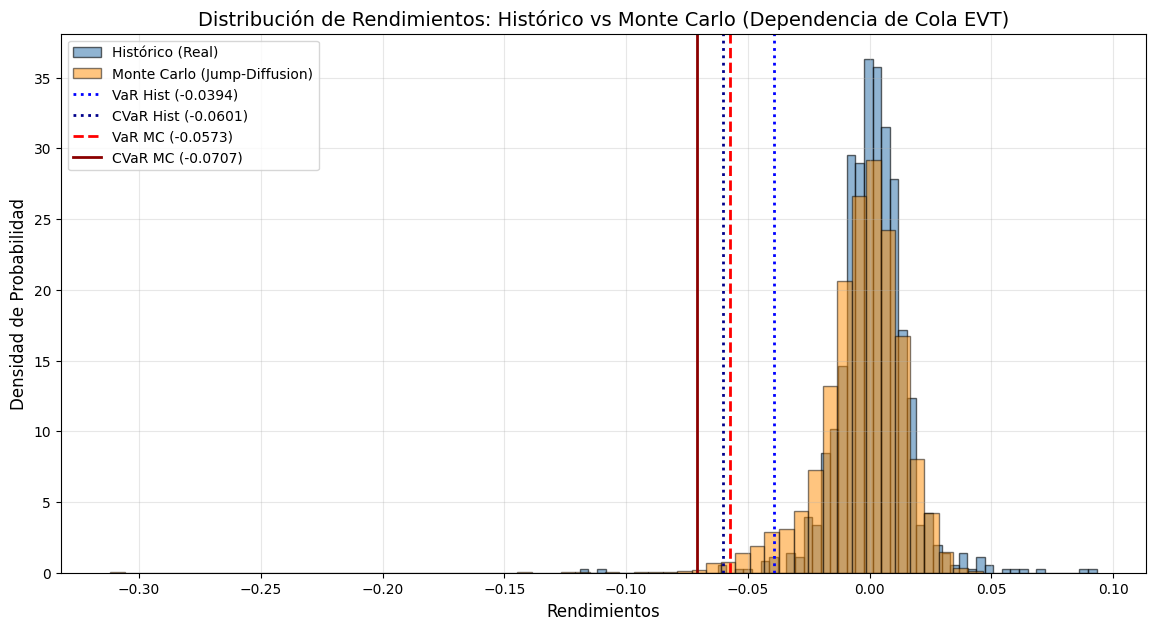

Pipeline ejecutado exitosamente.


In [ ]:
!pip install arch_model
!pip install arch yfinance
from arch import arch_model
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
from scipy.stats import ks_2samp, anderson_ksamp, genpareto
import warnings
import arch
import os

class RiesgoPortafolioEVTPipeline:
    def __init__(self, tickers, pesos, r=0.04, n_sims=10000, dt=1/360, alpha=0.01, umbral_pct=0.9):
        # 1. Parámetros estructurales
        self.tickers = tickers
        self.pesos = np.array(pesos)
        self.r = r
        self.n_sims = n_sims
        self.dt = dt
        self.alpha = alpha
        self.umbral_pct = umbral_pct   # Percentil para alta volatilidad y EVT (0.9 por defecto)

        # 2. Variables de Estado
        self.datos_historicos = None
        self.rendimientos_historicos = None
        self.matriz_cov = None
        self.matriz_corr = None
        self.volatilidades = None

        # Componentes del modelo GARCH y EVT
        self.garch_resultados = None
        self.vol_threshold = None      # Umbral de volatilidad del IVV
        self.df_parametros_gpd = None  # Matriz de parámetros GPD por activo
        self.vol_simulada_escenarios = None
        self.dN = None                 # Vector indicador de saltos extremos

        # Componentes de Simulación
        self.Z = None
        self.eta = None
        self.rendimientos_simulados = None
        self.portafolio_simulado = None
        self.portafolio_real = None

        # Métricas de Riesgo
        self.var_real = None
        self.cvar_real = None
        self.var_sim = None
        self.cvar_sim = None

    def ejecutar_pipeline(self, fecha_inicio='2020-01-01', fecha_fin='2024-01-01'):
        """Orquestador secuencial del pipeline."""
        print("Iniciando Pipeline VaR Monte Carlo con Dependencia de Cola EVT...")
        self._ingesta_datos(fecha_inicio, fecha_fin)
        self._calibrar_matriz_covarianza()
        self._calibrar_garch_y_evt()
        self._simular_montecarlo_con_saltos()
        self._calcular_metricas_riesgo()
        self._evaluar_bondad_ajuste()
        self._exportar_archivos()
        self._visualizar_resultados()
        print("Pipeline ejecutado exitosamente.")

    def _ingesta_datos(self, inicio, fin):
        """Módulo 1: Descarga y transformación."""
        print(f"Descargando datos históricos para: {self.tickers}")
        datos = yf.download(self.tickers, start=inicio, end=fin)['Close']
        self.datos_historicos = datos.dropna()
        self.rendimientos_historicos = np.log(self.datos_historicos / self.datos_historicos.shift(1)).dropna()
        self.portafolio_real = self.rendimientos_historicos.dot(self.pesos)

    def _calibrar_matriz_covarianza(self):
        """Módulo 2: Calibración de parámetros difusivos estándar."""
        print("Calibrando matriz de covarianza de la porción difusiva...")
        self.matriz_cov = self.rendimientos_historicos.cov() * 252
        self.matriz_corr = self.rendimientos_historicos.corr()
        self.volatilidades = self.rendimientos_historicos.std() * np.sqrt(252)

    def _calibrar_garch_y_evt(self):
        """
        Módulo 3: Pasos 1, 2, 3 y 4 del requerimiento.
        Ajuste de GJR-GARCH en IVV y ajuste de Pareto Generalizada (GPD) en activos.
        """
        print("Ajustando GJR-GARCH(1,1,1) para IVV con errores t-Student...")
        # Paso 1 y 2: Ajuste GARCH en IVV (S&P 500)
        rend_ivv = self.rendimientos_historicos['IVV'] * 100 # Escalamiento por convergencia numérica

        # Modelo de media con solo intercepto (Constant), Volatilidad GJR-GARCH (o=1), errores t
        am = arch_model(rend_ivv, mean='Constant', vol='GARCH', p=1, o=1, q=1, dist='t')
        self.garch_resultados = am.fit(disp='off')

        # Paso 3: Determinar el umbral de alta volatilidad (percentil 0.9)
        vol_condicional_hist = self.garch_resultados.conditional_volatility / 100 # Desescalar
        self.vol_threshold = np.percentile(vol_condicional_hist, self.umbral_pct * 100)
        print(f"Umbral de volatilidad extrema detectado: {self.vol_threshold:.4f}")

        # Paso 4: Ajuste de GPD (Peaks Over Threshold) para CADA activo
        print("Ajustando Distribución Pareto Generalizada (GPD) para cada activo...")
        parametros_gpd = []

        for ticker in self.tickers:
            # Trabajamos sobre las pérdidas (retornos negativos invertidos)
            perdidas = -self.rendimientos_historicos[ticker]
            # Umbral específico de pérdida del activo
            umbral_evt = np.percentile(perdidas, self.umbral_pct * 100)

            # Extraemos los excesos sobre el umbral
            excesos = perdidas[perdidas > umbral_evt] - umbral_evt

            # Ajuste de GPD fijando la locación en 0 (ya que ajustamos sobre excesos)
            forma, loc, escala = genpareto.fit(excesos, floc=0)
            parametros_gpd.append({
                'Activo': ticker,
                'Forma': forma,
                'Locacion': loc,
                'Escala': escala,
                'Umbral_Perdida': umbral_evt
            })

        self.df_parametros_gpd = pd.DataFrame(parametros_gpd)

    def _simular_montecarlo_con_saltos(self):
        """Módulo 4: Paso 5. Simulación de la Ecuación Integro-Diferencial."""
        print(f"Generando {self.n_sims} trayectorias con dinámica Jump-Diffusion...")
        num_activos = len(self.tickers)

        # Componente Difusivo (Movimiento Browniano Correlacionado)
        self.Z = np.random.standard_normal((self.n_sims, num_activos))
        L = np.linalg.cholesky(self.matriz_corr.values)
        self.eta = self.Z.dot(L.T)

        # Simulación de estados de volatilidad (Remuestreo de la volatilidad condicional)
        # Esto representa la asignación de un régimen de volatilidad a cada escenario
        vol_cond_hist = self.garch_resultados.conditional_volatility.values / 100
        self.vol_simulada_escenarios = np.random.choice(vol_cond_hist, size=self.n_sims)

        # Activador de Valores Extremos (dN_t)
        self.dN = (self.vol_simulada_escenarios > self.vol_threshold).astype(int)
        saltos_activados = np.sum(self.dN)
        print(f"Eventos extremos activados en la simulación: {saltos_activados} de {self.n_sims}")

        self.rendimientos_simulados = np.zeros_like(self.eta)

        for i, ticker in enumerate(self.tickers):
            sigma = self.volatilidades.iloc[i]
            params = self.df_parametros_gpd.iloc[i]

            # Parte difusiva continua: r*dt + sigma * eta * sqrt(dt)
            difusion = (self.r * self.dt) + (sigma * self.eta[:, i] * np.sqrt(self.dt))

            # Parte de saltos: nu_i * dN_t
            # Generamos valores aleatorios GPD para todos los escenarios
            nu_exceso = genpareto.rvs(c=params['Forma'], loc=params['Locacion'], scale=params['Escala'], size=self.n_sims)

            # El choque extremo total es el umbral base + el exceso GPD modelado
            magnitud_salto = params['Umbral_Perdida'] + nu_exceso

            # Restamos el salto multiplicado por el activador dN_t (caída en rendimiento)
            self.rendimientos_simulados[:, i] = difusion - (magnitud_salto * self.dN)

        self.portafolio_simulado = self.rendimientos_simulados.dot(self.pesos)

    def _calcular_metricas_riesgo(self):
        """Módulo 5: Cálculo de VaR y CVaR histórico y simulado."""
        print("Calculando Métricas de Riesgo...")

        # Histórico
        self.var_real = np.percentile(self.portafolio_real, self.alpha * 100)
        self.cvar_real = self.portafolio_real[self.portafolio_real <= self.var_real].mean()

        # Simulado (Monte Carlo)
        self.var_sim = np.percentile(self.portafolio_simulado, self.alpha * 100)
        self.cvar_sim = self.portafolio_simulado[self.portafolio_simulado <= self.var_sim].mean()

        print("-" * 50)
        print(f"MÉTRICAS DE RIESGO (Horizonte: dt={self.dt:.4f}, Confianza: {1-self.alpha:.2%})")
        print(f"VaR Histórico : {self.var_real:.6f} | CVaR Histórico : {self.cvar_real:.6f}")
        print(f"VaR Simulado  : {self.var_sim:.6f} | CVaR Simulado  : {self.cvar_sim:.6f}")
        print("-" * 50)

    def _evaluar_bondad_ajuste(self):
        """Módulo 6: Pruebas de eficiencia Kolmogorov-Smirnov y Anderson-Darling."""
        print("Ejecutando pruebas de eficiencia no paramétricas...")
        muestra_real = self.portafolio_real.values.flatten()
        muestra_simulada = self.portafolio_simulado.flatten()

        # KS Test
        ks_stat, ks_pvalue = ks_2samp(muestra_real, muestra_simulada)

        # AD Test
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            ad_stat, ad_crit_vals, ad_pvalue = anderson_ksamp([muestra_real, muestra_simulada])

        print("RESULTADOS DE BONDAD DE AJUSTE (Eficiencia del Monte Carlo)")
        print(f"KS Test -> Estadístico: {ks_stat:.4f}, P-value: {ks_pvalue:.4e}")
        print(f"AD Test -> Estadístico: {ad_stat:.4f}, P-value: {ad_pvalue:.4e}")
        print("Nota Analítica: Al incluir EVT, el test AD (que penaliza divergencias en las colas) ")
        print("debería mostrar un estadístico menor respecto al modelo difusivo puro.")
        print("-" * 50)

    def _exportar_archivos(self):
        """Módulo 7: Exportación requerida."""
        # Exportar parámetros GPD
        ruta_gpd = 'parametros_gpd_evt.csv'
        self.df_parametros_gpd.to_csv(ruta_gpd, index=False)
        print(f"Parámetros GPD exportados a: {ruta_gpd}")

        # Exportar simulación
        df_Z = pd.DataFrame(self.Z, columns=[f'Z_{t}' for t in self.tickers])
        df_eta = pd.DataFrame(self.eta, columns=[f'eta_{t}' for t in self.tickers])
        df_rend = pd.DataFrame(self.rendimientos_simulados, columns=[f'Rendimiento_{t}' for t in self.tickers])

        df_final = pd.concat([df_Z, df_eta, df_rend], axis=1)
        df_final['Volatilidad_IVV_Escenario'] = self.vol_simulada_escenarios
        df_final['Indicador_Activacion_dN'] = self.dN
        df_final['Portafolio_Simulado'] = self.portafolio_simulado

        ruta_sim = 'simulaciones_jump_diffusion_evt.csv'
        df_final.to_csv(ruta_sim, index=False)
        print(f"Simulaciones exportadas a: {ruta_sim}")

    def _visualizar_resultados(self):
        """Módulo 8: Graficación sobrepuesta con marcadores históricos y simulados."""
        print("Generando gráficos...")
        plt.figure(figsize=(14, 7))

        # Sobreposición de histogramas
        plt.hist(self.portafolio_real, bins=60, density=True, alpha=0.6, color='steelblue', edgecolor='black', label='Histórico (Real)')
        plt.hist(self.portafolio_simulado, bins=60, density=True, alpha=0.5, color='darkorange', edgecolor='black', label='Monte Carlo (Jump-Diffusion)')

        # Marcadores Históricos
        plt.axvline(self.var_real, color='blue', linestyle='dotted', linewidth=2, label=f'VaR Hist ({self.var_real:.4f})')
        plt.axvline(self.cvar_real, color='darkblue', linestyle='dotted', linewidth=2, label=f'CVaR Hist ({self.cvar_real:.4f})')

        # Marcadores Simulados
        plt.axvline(self.var_sim, color='red', linestyle='dashed', linewidth=2, label=f'VaR MC ({self.var_sim:.4f})')
        plt.axvline(self.cvar_sim, color='darkred', linestyle='solid', linewidth=2, label=f'CVaR MC ({self.cvar_sim:.4f})')

        plt.title('Distribución de Rendimientos: Histórico vs Monte Carlo (Dependencia de Cola EVT)', fontsize=14)
        plt.xlabel('Rendimientos', fontsize=12)
        plt.ylabel('Densidad de Probabilidad', fontsize=12)
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.show()

if __name__ == "__main__":
    tickers_portafolio = ['IVV', 'AVGO', 'LLY', 'NVDA', 'PM', 'WMT', 'XOM']
    pesos_portafolio = [0.008442, 0.097029, 0.307739, 0.19164, 0.220718, 0.106888, 0.067544]

    modelo_riesgo_avanzado = RiesgoPortafolioEVTPipeline(
        tickers=tickers_portafolio,
        pesos=pesos_portafolio,
        r=0.04,
        n_sims=10000,
        dt=1/360,
        alpha=0.01,
        umbral_pct=0.9
    )

    modelo_riesgo_avanzado.ejecutar_pipeline(fecha_inicio='2020-01-01', fecha_fin='2024-01-01')